## Ejercicio 8: Análisis exploratorio adicional

In [12]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

sys.path.append("..")

from src.config import LAGOS
from src.download import DATA_RAW
from src.indices import compute_indices
from src.mask import get_water_mask

plt.rcParams["figure.dpi"] = 100
UMBRAL_FLORACION = 20
lagos = ["atitlan", "amatitlan"]

RANGO_VALIDO = (-10, 100)  # rango físicamente plausible de clorofila-a (mg/m3)

def limpiar(arr):
    return np.where((arr >= RANGO_VALIDO[0]) & (arr <= RANGO_VALIDO[1]), arr, np.nan)

### 8.1 Extensión espacial de la floración (% del lago con valores altos)

In [15]:
filas_extension = []
for lago, datos in LAGOS.items():
    for fecha in datos["fechas"]:
        tif_path = DATA_RAW / lago / f"{fecha}.tif"
        idx = compute_indices(lago, fecha)
        water = get_water_mask(lago, tif_path, idx["ndwi"])
        ciano = limpiar(idx["cianobacteria"])
        valid = water & ~np.isnan(ciano)
        pct_floracion = 100 * (valid & (ciano > UMBRAL_FLORACION)).sum() / valid.sum() if valid.sum() > 0 else np.nan
        filas_extension.append({"lago": lago, "fecha": pd.to_datetime(fecha), "pct_floracion": pct_floracion})

extension = pd.DataFrame(filas_extension).sort_values(["lago", "fecha"])
print(extension)

         lago      fecha  pct_floracion
11  amatitlan 2025-01-28      19.894244
12  amatitlan 2025-04-15       5.233190
13  amatitlan 2025-04-28      15.277918
14  amatitlan 2025-11-24      11.254216
15  amatitlan 2026-01-08      31.500060
16  amatitlan 2026-02-02       0.357092
17  amatitlan 2026-02-07       2.946920
18  amatitlan 2026-03-29      15.197646
19  amatitlan 2026-04-13      20.332893
20  amatitlan 2026-04-28      28.848790
21  amatitlan 2026-06-19      76.106256
0     atitlan 2025-01-18      34.785847
1     atitlan 2025-04-13       0.260125
2     atitlan 2025-05-13       0.214929
3     atitlan 2025-07-17       0.523622
4     atitlan 2025-11-21       5.728384
5     atitlan 2025-12-29       1.850260
6     atitlan 2026-02-12       3.801964
7     atitlan 2026-03-24       0.305549
8     atitlan 2026-04-13       0.254887
9     atitlan 2026-04-28       0.190920
10    atitlan 2026-07-22       0.382985


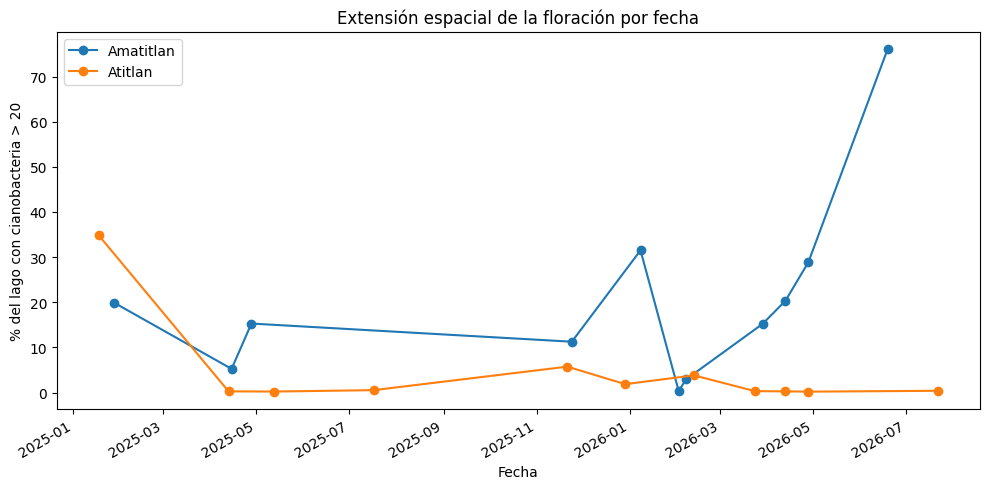

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
for lago, g in extension.groupby("lago"):
    ax.plot(g["fecha"], g["pct_floracion"], marker="o", label=lago.capitalize())
ax.set_xlabel("Fecha")
ax.set_ylabel(f"% del lago con cianobacteria > {UMBRAL_FLORACION}")
ax.set_title("Extensión espacial de la floración por fecha")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Hallazgos**

Amatitlán presenta una tendencia creciente y bastante variable en la extensión de las floraciones durante el período analizado, alcanzando su punto máximo el 19 de junio de 2026, cuando el 76,1 % del lago se encontraba en floración. Este resultado coincide con el pico temporal identificado previamente en el Ejercicio 4, reforzando la evidencia de un evento de floración particularmente intenso en esa fecha.

En contraste, Atitlán mantiene una proporción de floración generalmente baja, inferior al 6 % en casi todas las fechas. La principal excepción ocurre el 18 de enero de 2025, cuando se estimó una floración del 34,8 % del lago. Este valor se mantiene incluso después de filtrar los valores físicamente imposibles, por lo que no parece ser simplemente un artefacto producido por el cálculo.

No obstante, dado que este comportamiento no vuelve a observarse en las demás fechas analizadas, se considera un evento aislado y no una evidencia suficiente para establecer una tendencia de floración en Atitlán. Sería conveniente verificar esta fecha en particular para determinar si corresponde a una floración puntual real o si pudo estar influenciada por condiciones atmosféricas u ópticas específicas de la imagen.

### 8.2 Zonas persistentes de acumulación

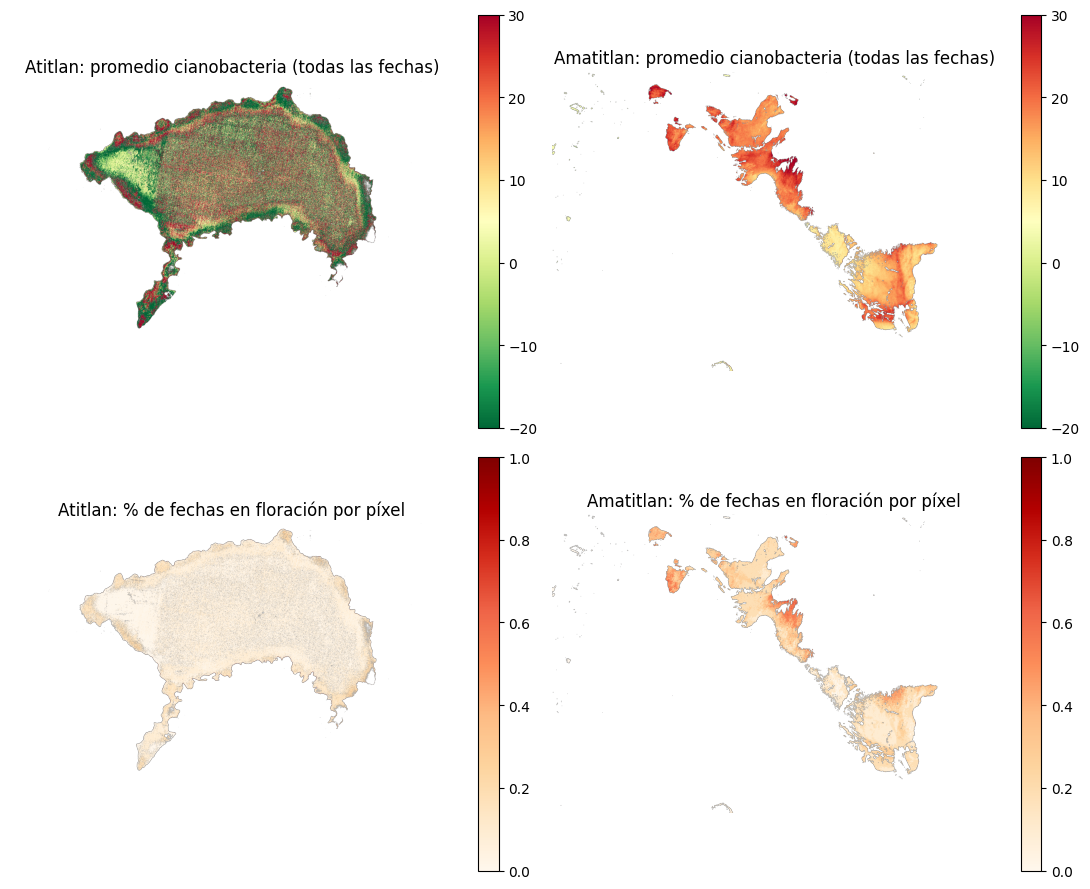

In [17]:
def acumular_indicador(lago, indicador, umbral):
    suma = conteo_valido = conteo_floracion = None
    for fecha in LAGOS[lago]["fechas"]:
        tif_path = DATA_RAW / lago / f"{fecha}.tif"
        idx = compute_indices(lago, fecha)
        water = get_water_mask(lago, tif_path, idx["ndwi"])
        arr = idx[indicador]
        valid = water & ~np.isnan(arr)

        if suma is None:
            suma = np.zeros_like(arr, dtype=np.float64)
            conteo_valido = np.zeros_like(arr, dtype=np.int32)
            conteo_floracion = np.zeros_like(arr, dtype=np.int32)

        suma[valid] += arr[valid]
        conteo_valido[valid] += 1
        conteo_floracion[valid & (arr > umbral)] += 1

        del idx, water, arr, valid
        gc.collect()

    media = np.where(conteo_valido > 0, suma / np.maximum(conteo_valido, 1), np.nan)
    frecuencia = np.where(conteo_valido > 0, conteo_floracion / np.maximum(conteo_valido, 1), np.nan)
    agua_comun = conteo_valido == len(LAGOS[lago]["fechas"])
    return media, frecuencia, agua_comun

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for j, lago in enumerate(lagos):
    media, frecuencia, agua_comun = acumular_indicador(lago, "cianobacteria", UMBRAL_FLORACION)

    im0 = axes[0, j].imshow(np.where(agua_comun, media, np.nan), cmap="RdYlGn_r", vmin=-20, vmax=30)
    axes[0, j].set_title(f"{lago.capitalize()}: promedio cianobacteria (todas las fechas)")
    axes[0, j].axis("off")
    fig.colorbar(im0, ax=axes[0, j], fraction=0.046)

    im1 = axes[1, j].imshow(np.where(agua_comun, frecuencia, np.nan), cmap="OrRd", vmin=0, vmax=1)
    axes[1, j].set_title(f"{lago.capitalize()}: % de fechas en floración por píxel")
    axes[1, j].axis("off")
    fig.colorbar(im1, ax=axes[1, j], fraction=0.046)

plt.tight_layout()
plt.show()

### 8.3 Comparación de distribuciones entre fechas (histogramas, boxplots, mapas de diferencia)

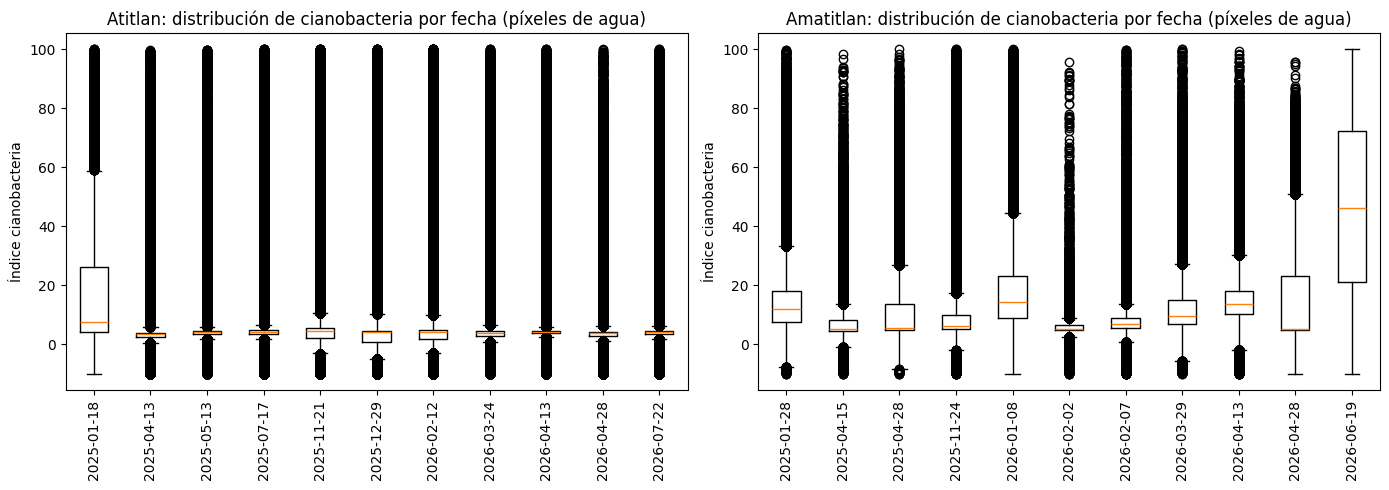

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lago, ax in zip(lagos, axes):
    datos_por_fecha = []
    for fecha in LAGOS[lago]["fechas"]:
        tif_path = DATA_RAW / lago / f"{fecha}.tif"
        idx = compute_indices(lago, fecha)
        water = get_water_mask(lago, tif_path, idx["ndwi"])
        ciano_limpio = limpiar(idx["cianobacteria"])
        valid = water & ~np.isnan(ciano_limpio)
        datos_por_fecha.append(ciano_limpio[valid])
        del idx, water, ciano_limpio, valid
        gc.collect()

    ax.boxplot(datos_por_fecha, tick_labels=LAGOS[lago]["fechas"], vert=True)
    ax.set_title(f"{lago.capitalize()}: distribución de cianobacteria por fecha (píxeles de agua)")
    ax.set_ylabel("Índice cianobacteria")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

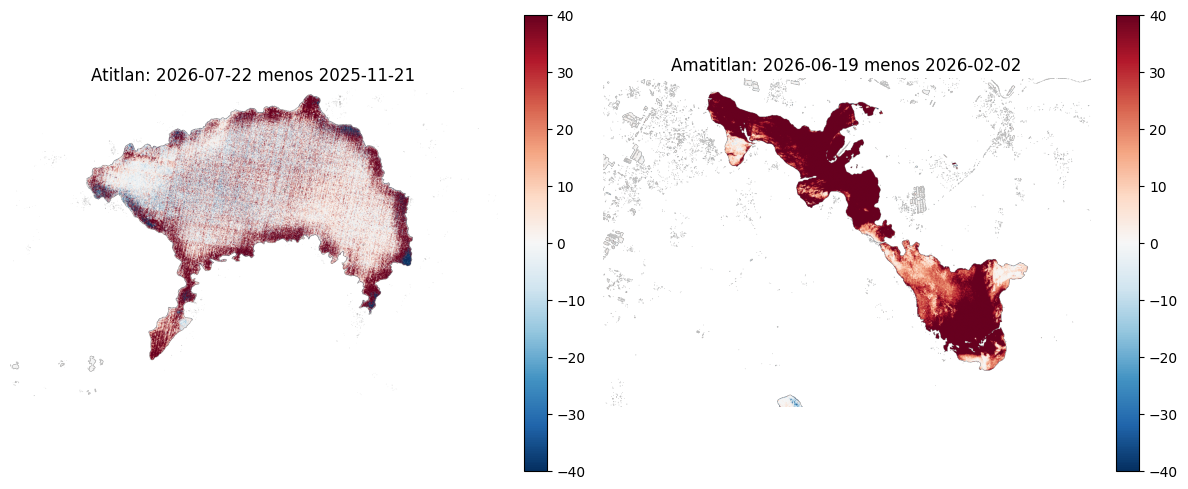

In [20]:
tabla = pd.read_csv("../data/processed/tabla_temporal.csv", parse_dates=["fecha"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lago in zip(axes, lagos):
    g = tabla[tabla["lago"] == lago]
    fecha_max = g.loc[g["cianobacteria"].idxmax(), "fecha"].strftime("%Y-%m-%d")
    fecha_min = g.loc[g["cianobacteria"].idxmin(), "fecha"].strftime("%Y-%m-%d")

    idx_max = compute_indices(lago, fecha_max)
    idx_min = compute_indices(lago, fecha_min)
    tif_max = DATA_RAW / lago / f"{fecha_max}.tif"
    water = get_water_mask(lago, tif_max, idx_max["ndwi"])

    diff = np.where(water, idx_max["cianobacteria"] - idx_min["cianobacteria"], np.nan)
    im = ax.imshow(diff, cmap="RdBu_r", vmin=-40, vmax=40)
    ax.set_title(f"{lago.capitalize()}: {fecha_max} menos {fecha_min}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

**Hallazgos**

Después de filtrar los valores no plausibles, los boxplots muestran comportamientos bastante diferentes entre ambos lagos.

En **Atitlán**, las medianas se mantienen bajas y relativamente estables, alrededor de 3–7, durante casi todo el período analizado. Aunque en todas las fechas aparecen algunos valores elevados, estos se presentan como puntos aislados y no son suficientes para modificar la distribución general del lago. Esto indica que existen algunos sectores con valores altos, pero que no representan un comportamiento generalizado en la superficie del lago.

En **Amatitlán**, en cambio, se observa un aumento progresivo de las medianas hacia el final del período. El cambio más evidente ocurre el 19 de junio de 2026, cuando la mediana alcanza aproximadamente 46 y el rango intercuartílico se amplía considerablemente (≈21–72). Esto es importante porque el aumento no se limita a unos pocos valores extremos, la distribución completa se desplaza hacia valores más altos, lo que indica que la floración afectó una porción amplia del lago.

El mapa de diferencia refuerza este comportamiento desde una perspectiva espacial. En **Atitlán**, el cambio entre la fecha con menor valor (2025-11-21) y la de mayor valor (2026-07-22) es leve y se distribuye de manera relativamente uniforme sobre la superficie. En **Amatitlán**, por el contrario, el aumento entre la fecha con menor valor (2026-02-02) y el pico (2026-06-19) se concentra principalmente en el **brazo o bahía noroeste**. Esta coincidencia es especialmente relevante porque la misma zona ya había sido identificada como un hotspot en el mapa de persistencia (8.2). El hecho de que ambos análisis, realizados desde enfoques diferentes, señalen el mismo sector proporciona evidencia adicional de que esta bahía constituye una zona recurrente de acumulación de la floración, y no simplemente un resultado aislado o producto del azar.

### 8.4 ¿Existe un patrón estacional?

In [21]:
tabla["mes"] = tabla["fecha"].dt.month
tabla["temporada"] = tabla["mes"].apply(lambda m: "seca" if m in [11, 12, 1, 2, 3, 4] else "lluviosa")

resumen_estacional = tabla.groupby(["lago", "temporada"])["cianobacteria"].agg(["mean", "std", "count"])
resumen_estacional

mean        std  count
lago      temporada                             
amatitlan lluviosa   53.374084        NaN      1
          seca       12.068011   3.986014     10
atitlan   lluviosa    2.869084   0.555655      3
          seca      -13.178976  19.817253      8

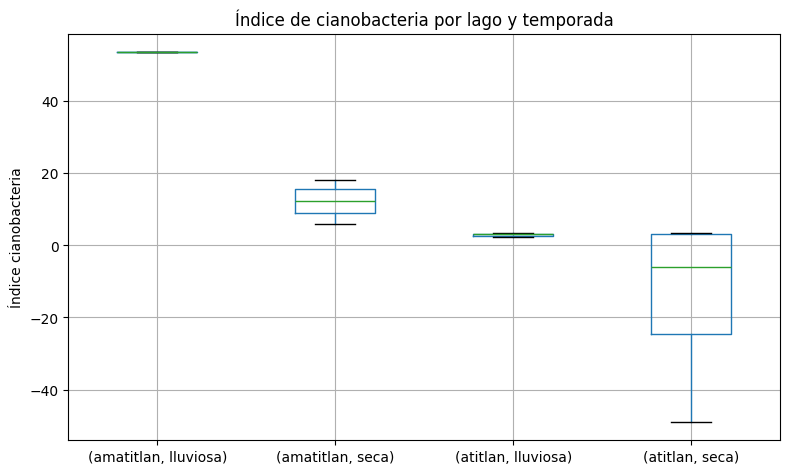

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
tabla.boxplot(column="cianobacteria", by=["lago", "temporada"], ax=ax)
ax.set_title("Índice de cianobacteria por lago y temporada")
plt.suptitle("")
ax.set_xlabel("")
ax.set_ylabel("Índice cianobacteria")
plt.tight_layout()
plt.show()

**Hallazgos**

- **Amatitlán:** el promedio en temporada seca es ≈ 12.1 (con solo 10 fechas secas), y la única fecha de temporada lluviosa disponible (2026-06-19) tiene el valor más alto de toda la serie (≈ 53.4). Con una sola observación en lluviosa no se puede concluir estadísticamente un patrón estacional, pero es consistente con la hipótesis de que el inicio de la temporada de lluvias arrastra nutrientes (escorrentía agrícola/urbana) hacia el lago y dispara la floración.

- **Atitlán:** en temporada seca el promedio es marcadamente negativo (≈ −13.2, con alta dispersión, std ≈ 19.8), mientras que en temporada lluviosa el promedio es positivo y mucho más estable (≈ 2.9, std ≈ 0.56). Esto sugiere que en época seca hay mayor variabilidad (posiblemente por estratificación térmica o condiciones ópticas del agua más cambiantes), mientras que en lluviosa el índice se mantiene consistentemente bajo pero positivo (sin evidencia de floraciones fuertes en ninguna temporada).

### 8.5 Síntesis del análisis exploratorio adicional

**Extensión (8.1)**: Amatitlán presenta una floración más extensa y variable, con un pico del 76 % en junio de 2026. Atitlán se mantiene bajo casi todo el período, salvo por el evento aislado del 35 % en enero de 2025.

**Persistencia (8.2)**: Amatitlán presenta una zona de acumulación persistente en la bahía noroeste, posiblemente relacionada con menor circulación, poca profundidad o aporte de nutrientes. Atitlán no muestra una zona persistente comparable.

**Distribución (8.3)**: En Atitlán predominan valores bajos con algunos focos puntuales. En Amatitlán, la distribución completa aumenta durante junio de 2026, indicando una floración que afectó una parte amplia del lago.

**Estacionalidad (8.4)**: Amatitlán presenta un valor notablemente mayor durante la temporada lluviosa, mientras que Atitlán no muestra un patrón estacional claro. Sin embargo, el número de observaciones por temporada es insuficiente para confirmarlo estadísticamente.

**Síntesis general**: Los distintos análisis apuntan a un mismo patrón, Amatitlán presenta una proliferación creciente y espacialmente concentrada en la bahía noroeste, especialmente hacia junio de 2026. Atitlán mantiene niveles bajos y dispersos, con una única fecha anómala que debe considerarse un evento aislado y no una tendencia confirmada.